# Three-Way Benchmark Analysis: pure_ns3 vs. ns3sionna vs. sionnart

This notebook analyzes the performance results of the three-way benchmark conducted on the Grace-Blackwell architecture. The benchmark compares three different backends for simulating wireless networks with ray-tracing based propagation:

1. **pure_ns3**: Standard ns-3 with simple stochastic propagation models (baseline).
2. **ns3sionna**: ns-3 integrated with Sionna via an external ZMQ server (Python process).
3. **sionnart**: ns-3 with Sionna RT embedded directly using `pybind11` and aggressive C++ caching.

## Environment and Setup
- **Hardware**: NVIDIA Grace-Blackwell (GB10) system.
- **Scenarios**: 
    - `stationary_high_load`: Static nodes, high traffic.
    - `low_mob_low_load`: Low mobility (random walk), low traffic.
    - `high_mob_high_load`: High mobility, high traffic (worst case for ray-tracing).
- **Simulation Time**: 9 seconds per run.
- **Max STAs**: 32 STAs + 1 AP.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv('results.csv')

# Cleanup
df = df.dropna(how='all')
df['num_stas'] = df['num_stas'].astype(int)

# Adjust ns3sionna memory usage to include the ZMQ server baseline (~358 MiB)
# This makes it comparable to sionnart which includes the interpreter footprint.
server_baseline = 358
df.loc[df['backend'] == 'ns3sionna', 'sim_mem_usage_mib'] += server_baseline

# Display first few rows
df.head(10)

,backend,regime,num_stas,wall_clock_s,sim_mem_usage_mib,peak_util_percent
0,ns3sionna,high_mob_high_load,1,4.820830,514,13
1,ns3sionna,high_mob_high_load,2,14.938100,384,11
2,ns3sionna,high_mob_high_load,4,41.311500,390,9
3,ns3sionna,high_mob_high_load,8,156.405000,538,11
4,ns3sionna,high_mob_high_load,16,622.365000,1700,11
5,ns3sionna,high_mob_high_load,32,1871.600000,1883,96
6,ns3sionna,stationary_high_load,1,0.266142,358,0
7,ns3sionna,stationary_high_load,2,0.488345,358,0
8,ns3sionna,stationary_high_load,4,1.504200,358,3
9,ns3sionna,stationary_high_load,8,5.017830,358,0


## 1. Wall-Clock Performance Comparison

We plot the wall-clock time required for 9 seconds of simulation vs. the number of STAs.

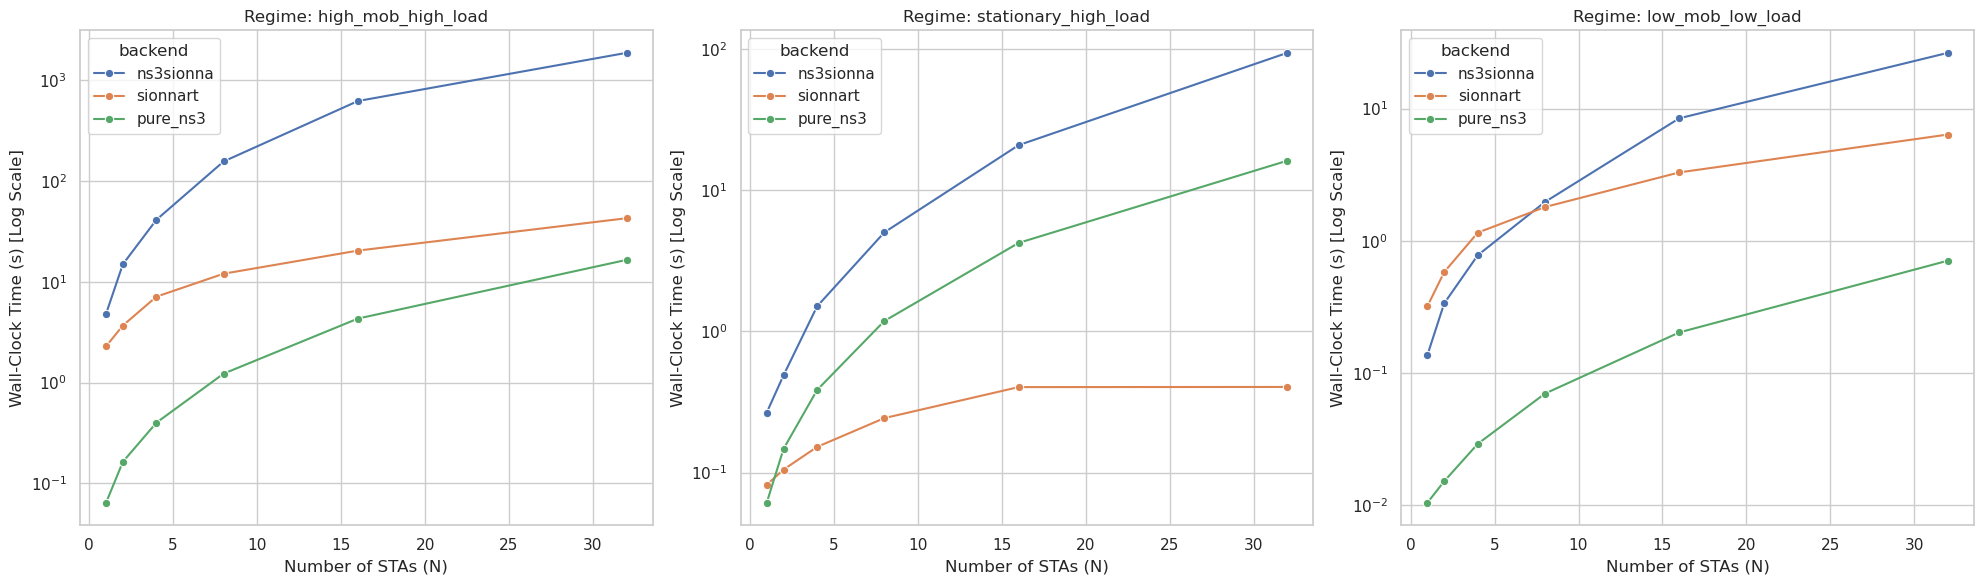

In [2]:
sns.set_theme(style="whitegrid")
regimes = df['regime'].unique()
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for i, regime in enumerate(regimes):
    regime_df = df[df['regime'] == regime]
    sns.lineplot(data=regime_df, x="num_stas", y="wall_clock_s", hue="backend", marker="o", ax=axes[i])
    axes[i].set_title(f"Regime: {regime}")
    axes[i].set_yscale("log")
    axes[i].set_xlabel("Number of STAs (N)")
    axes[i].set_ylabel("Wall-Clock Time (s) [Log Scale]")

plt.tight_layout()
plt.show()

## 2. Speedup Analysis

We calculate the speedup of **sionnart** relative to **ns3sionna**.

In [3]:
# Pivot to get backends as columns
pivot_df = df.pivot_table(index=['regime', 'num_stas'], columns='backend', values='wall_clock_s').reset_index()

# Calculate speedup
if 'ns3sionna' in pivot_df.columns and 'sionnart' in pivot_df.columns:
    pivot_df['sionnart_speedup_vs_zmq'] = pivot_df['ns3sionna'] / pivot_df['sionnart']
if 'pure_ns3' in pivot_df.columns and 'sionnart' in pivot_df.columns:
    pivot_df['sionnart_speedup_vs_pure'] = pivot_df['pure_ns3'] / pivot_df['sionnart']

print("Speedup Summary (sionnart vs others):")
display(pivot_df.head(20))

Speedup Summary (sionnart vs others):


backend,regime,num_stas,ns3sionna,pure_ns3,sionnart,sionnart_speedup_vs_zmq,sionnart_speedup_vs_pure
0,high_mob_high_load,1,4.820830,0.064234,2.293,2.102412,0.028013
1,high_mob_high_load,2,14.938100,0.163703,3.684,4.054859,0.044436
2,high_mob_high_load,4,41.311500,0.400312,7.124,5.798919,0.056192
3,high_mob_high_load,8,156.405000,1.227120,12.037,12.993686,0.101946
4,high_mob_high_load,16,622.365000,4.319730,20.405,30.500613,0.211700
5,high_mob_high_load,32,1871.600000,16.515800,42.772,43.757598,0.386136
6,low_mob_low_load,1,0.136592,0.010425,0.320,0.426850,0.032578
7,low_mob_low_load,2,0.336198,0.015161,0.580,0.579652,0.026141
8,low_mob_low_load,4,0.778042,0.029097,1.153,0.674798,0.025236
9,low_mob_low_load,8,1.966300,0.069811,1.801,1.091782,0.038763


## 3. GPU Resource Utilization (Grace-Blackwell)

This section analyzes the GPU memory and compute utilization scaling. We show the breakdown by regime to reveal how mobility and load impact the footprint.

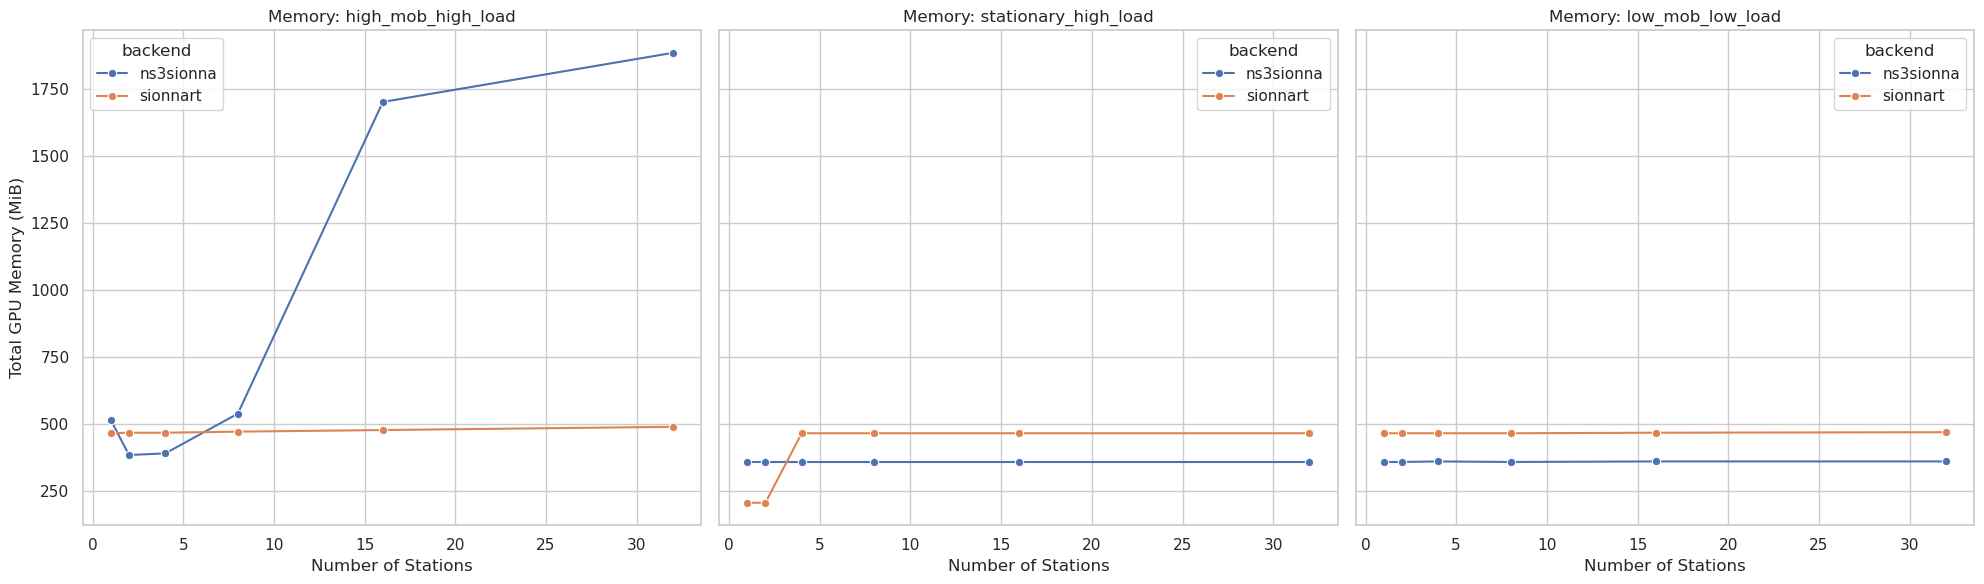

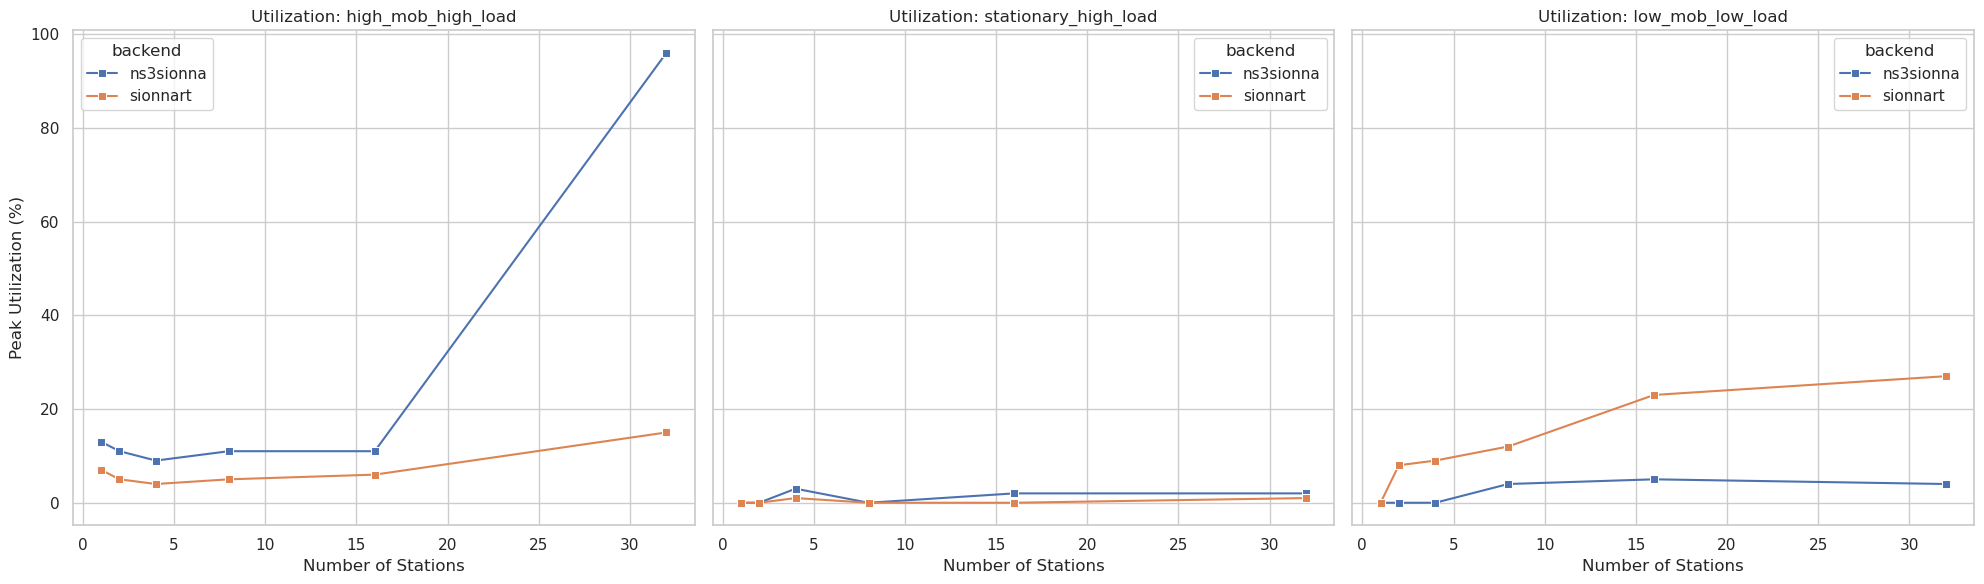

GPU Footprint Summary (max across all regimes):


,sim_mem_usage_mib,peak_util_percent
backend,,
ns3sionna,1883,96
sionnart,489,27


In [4]:
# Filter for backends that use the GPU
gpu_df = df[df['backend'] != 'pure_ns3'].copy()

# Plot GPU Memory Usage by Regime
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for i, regime in enumerate(regimes):
    regime_df = gpu_df[gpu_df['regime'] == regime]
    sns.lineplot(data=regime_df, x='num_stas', y='sim_mem_usage_mib', hue='backend', marker='o', ax=axes[i])
    axes[i].set_title(f"Memory: {regime}")
    axes[i].set_xlabel("Number of Stations")
    axes[i].set_ylabel("Total GPU Memory (MiB)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# Plot GPU Utilization by Regime
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for i, regime in enumerate(regimes):
    regime_df = gpu_df[gpu_df['regime'] == regime]
    sns.lineplot(data=regime_df, x='num_stas', y='peak_util_percent', hue='backend', marker='s', ax=axes[i])
    axes[i].set_title(f"Utilization: {regime}")
    axes[i].set_xlabel("Number of Stations")
    axes[i].set_ylabel("Peak Utilization (%)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# Summary Statistics (across all regimes)
print("GPU Footprint Summary (max across all regimes):")
display(gpu_df.groupby('backend')[['sim_mem_usage_mib', 'peak_util_percent']].max())